In [4]:
import mlflow
model = mlflow.pyfunc.load_model('models:/crowd_counting/49')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [5]:

import numpy as np
dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
# model.predict(dummy_input)

In [6]:
model.predict(dummy_input)

[{'count': 558.9382934570312,
  'density_map': array([[0.0007944 , 0.00083758, 0.0009561 , ..., 0.00058196, 0.00068547,
          0.00072797],
         [0.00071545, 0.00077807, 0.00082477, ..., 0.00065658, 0.00080366,
          0.00067735],
         [0.00075343, 0.00081019, 0.0008973 , ..., 0.00063075, 0.00072392,
          0.00064276],
         ...,
         [0.00099767, 0.00114603, 0.00092705, ..., 0.00067747, 0.00062252,
          0.00063412],
         [0.00088843, 0.00093368, 0.00072342, ..., 0.00068083, 0.00071532,
          0.00069199],
         [0.00080175, 0.00077028, 0.00065359, ..., 0.00067804, 0.00071668,
          0.00072591]], shape=(704, 1056), dtype=float32)},
 {'count': 558.3277587890625,
  'density_map': array([[0.00081163, 0.00081266, 0.00086329, ..., 0.00068445, 0.00072155,
          0.00069902],
         [0.00087198, 0.00079846, 0.00070469, ..., 0.00061695, 0.00061345,
          0.0006983 ],
         [0.00089803, 0.00084331, 0.0007952 , ..., 0.0006397 , 0.00058606,


In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
from src import config
import numpy as np
from src.utils import visualization as vis
from src.utils import helpers
from src.core.params import BaseParams
from src.models.model import CrowdCounter
from src.data.datamodule import CrowdDataModule

In [ ]:
from src.utils.model_registry.utils import get_existing_code_files


get_existing_code_files()

In [ ]:
config.DATASET_PATH

In [10]:
dataset_path = f'{config.DATA_HOME}/jhu-crowd-pp-v2'

In [12]:
!kaggle datasets download -d swapnilbagde000/jhu-crowdv2-density-maps -p $dataset_path --unzip

Dataset URL: https://www.kaggle.com/datasets/swapnilbagde000/jhu-crowdv2-density-maps
License(s): CC0-1.0

  0%|                                               | 0.00/1.92G [00:00<?, ?B/s]
  1%|▍                                     | 25.0M/1.92G [00:01<01:18, 26.0MB/s]
  3%|█▏                                    | 62.0M/1.92G [00:02<00:59, 33.2MB/s]
  6%|██▎                                    | 118M/1.92G [00:03<00:43, 44.6MB/s]
 10%|███▉                                   | 197M/1.92G [00:04<00:31, 59.4MB/s]
 13%|█████▏                                 | 259M/1.92G [00:05<00:29, 61.4MB/s]
 19%|███████▏                               | 364M/1.92G [00:06<00:21, 77.6MB/s]
 23%|█████████                              | 457M/1.92G [00:07<00:19, 81.0MB/s]
 28%|██████████▊                            | 547M/1.92G [00:08<00:17, 85.0MB/s]
 34%|█████████████▏                         | 661M/1.92G [00:09<00:14, 93.6MB/s]
 39%|███████████████                        | 758M/1.92G [00:10<00:13, 95.9MB/s]
 4

[1.039e-03 1.037e-03 1.036e-03 ... 5.960e-08 5.960e-08 5.960e-08]


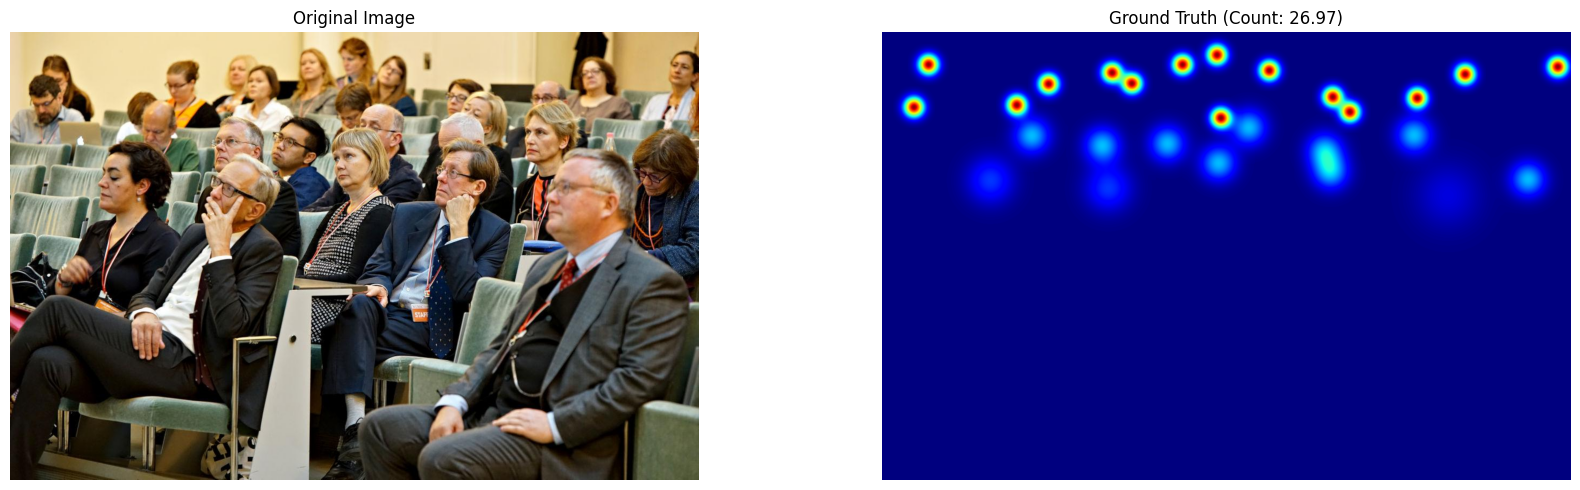

In [13]:
img, target, count = helpers.get_sample_from_ds(index=2200)
print(np.sort(target[target > 0])[::-1])
vis.visualize_sample(img, (target, count), cmap='jet')

In [2]:
params = BaseParams(aug_factor=0.12, crop_size=256)
model = CrowdCounter(params)

Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, downsamp_modules.0.0.bias, downsamp_modules.0.0.weight, downsamp_modules.0.1.bias, downsamp_modules.0.1.running_mean, downsamp_modules.0.1.running_var, downsamp_modules.0.1.weight, downsamp_modules.1.0.bias, downsamp_modules.1.0.weight, downsamp_modules.1.1.bias, downsamp_modules.1.1.running_mean, downsamp_modules.1.1.running_var, downsamp_modules.1.1.weight, downsamp_modules.2.0.bias, downsamp_modules.2.0.weight, downsamp_modules.2.1.bias, downsamp_modules.2.1.running_mean, downsamp_modules.2.1.running_var, downsamp_modules.2.1.weight, final_layer.0.bias, final_layer.0.weight, final_layer.1.bias, final_layer.1.running_mean, final_layer.1.running_var, final_layer.1.weight, classifier.bias, classifier.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup()

In [4]:
sample = helpers.get_sample_from_dm(datamodule)
sample.shape

torch.Size([1, 3, 672, 992])

In [ ]:
vis.visualize_model_graph(model, sample=sample)

In [ ]:
from torchview import draw_graph
model_graph = draw_graph(model, input_size=sample.shape, expand_nested=True, depth=100)
model_graph.visual_graph